<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Lab: Exploratory Data Analysis**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis or EDA. 


## Objectives


In this lab, you will perform the following:


- Examine the structure of a dataset.

- Handle missing values effectively.

- Conduct summary statistics on key columns.

- Analyze employment status, job satisfaction, programming language usage, and trends in remote work.


## Hands on Lab


#### Step 1: Install and Import Libraries


Install the necessary libraries for data manipulation and visualization.


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Step 2: Load and Preview the Dataset
Load the dataset from the provided URL. Use df.head() to display the first few rows to get an overview of the structure.


In [2]:
# Load the Stack Overflow survey data
file_name = "survey_data.csv"
df = pd.read_csv(file_name)
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


#### Step 3: Handling Missing Data


Identify and manage missing values in critical columns such as `Employment`, `JobSat`, and `RemoteWork`. Implement a strategy to fill or drop these values, depending on the significance of the missing data.


In [3]:
## Write your code here
median_value = df["JobSat"].median()
df["JobSat"].fillna(median_value , inplace= True)
max_value = df["RemoteWork"].value_counts().idxmax()
df["RemoteWork"].fillna(max_value , inplace = True)

C:\Users\Abdullah\AppData\Local\Temp\ipykernel_11588\342125180.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["JobSat"].fillna(median_value , inplace= True)
C:\Users\Abdullah\AppData\Local\Temp\ipykernel_11588\342125180.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

#### Step 4: Analysis of Experience and Job Satisfaction


Analyze the relationship between years of professional coding experience (`YearsCodePro`) and job satisfaction (`JobSat`). Summarize `YearsCodePro` and calculate median satisfaction scores based on experience ranges.

- Create experience ranges for `YearsCodePro` (e.g., `0-5`, `5-10`, `10-20`, `>20` years).

- Calculate the median `JobSat` for each range.

- Visualize the relationship using a bar plot or similar visualization.


In [4]:
## Write your code here
# df["YearsCodePro"].unique()

df["YearsCodePro"]= df["YearsCodePro"].replace({
    'Less than 1 year': 0,
    'More than 50 years': 51
})
df["YearsCodePro"].unique()


df["YearsCodePro"] = pd.to_datetime(df["YearsCodePro"] , errors="coerce" )
df["YearsCodePro"] = df["YearsCodePro"].fillna(0)

df["YearsCodePro"]



C:\Users\Abdullah\AppData\Local\Temp\ipykernel_11588\3978741324.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["YearsCodePro"] = pd.to_datetime(df["YearsCodePro"] , errors="coerce" )


0        0
1        0
2        0
3        0
4        0
        ..
65432    0
65433    0
65434    0
65435    0
65436    0
Name: YearsCodePro, Length: 65437, dtype: object

In [5]:
# 1. تحويل العمود إلى أرقام وإجبار أي قيم غير متوافقة (مثل التواريخ) على التحول لـ NaN
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# 2. الآن تعامل مع القيم المفقودة (التي نتجت عن الخطأ أو كانت فارغة أصلاً)
# سنملأها بـ 0 (أو يمكنك حذفها)
df['YearsCodePro'] = df['YearsCodePro'].fillna(0).astype(int)

# 3. الآن جرب تنفيذ التقسيم (هنا لن يظهر الخطأ بإذن الله)
bins = [0, 5, 10, 20, 100]
labels = ['0-5 years', '5-10 years', '10-20 years', '>20 years']
df['ExperienceRange'] = pd.cut(df['YearsCodePro'], bins=bins, labels=labels, include_lowest=True)

# 4. حساب الوسيط للرضا
experience_analysis = df.groupby('ExperienceRange', observed=True)['JobSat'].median().reset_index()
experience_analysis


,ExperienceRange,JobSat
0,0-5 years,7.0


#### Step 5: Visualize Job Satisfaction


Use a count plot to show the distribution of `JobSat` values. This provides insights into the overall satisfaction levels of respondents.


C:\Users\Abdullah\AppData\Local\Temp\ipykernel_11588\717059379.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="JobSat", palette="viridis")


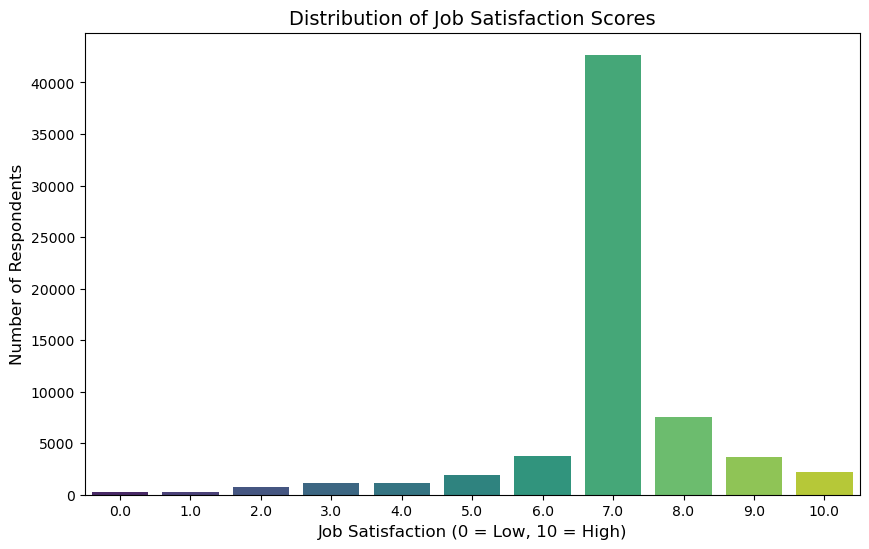

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. تحديد حجم الرسم ليكون واضحاً
plt.figure(figsize=(10, 6))

# 2. رسم الـ Count Plot
# نستخدم x="JobSat" ليعرض الدرجات على المحور الأفقي
sns.countplot(data=df, x="JobSat", palette="viridis")

# 3. إضافة العناوين لتوضيح الرسم
plt.title("Distribution of Job Satisfaction Scores", fontsize=14)
plt.xlabel("Job Satisfaction (0 = Low, 10 = High)", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)

# 4. عرض الرسم
plt.show()

#### Step 6: Analyzing Remote Work Preferences by Job Role


Analyze trends in remote work based on job roles. Use the `RemoteWork` and `Employment` columns to explore preferences and examine if specific job roles prefer remote work more than others.

- Use a count plot to show remote work distribution.

- Cross-tabulate remote work preferences by employment type (e.g., full-time, part-time) and job roles.


C:\Users\Abdullah\AppData\Local\Temp\ipykernel_11588\270545226.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df.dropna(subset=['RemoteWork']), x='RemoteWork', palette='pastel')


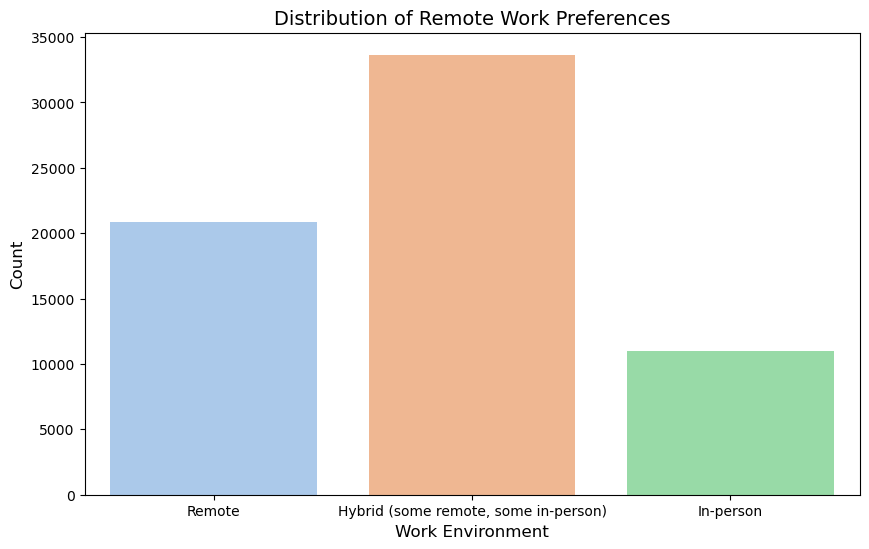

In [7]:
## Write your code here
# 1. إعداد مساحة الرسم
plt.figure(figsize=(10, 6))

# 2. رسم توزيع العمل عن بعد
# ملاحظة: تأكد من تنظيف القيم المفقودة (NaN) لرسم أوضح
sns.countplot(data=df.dropna(subset=['RemoteWork']), x='RemoteWork', palette='pastel')

# 3. العناوين والتسميات
plt.title('Distribution of Remote Work Preferences', fontsize=14)
plt.xlabel('Work Environment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [8]:
# إنشاء جدول تقاطعي بين نوع التوظيف وبيئة العمل
remote_employment_cross = pd.crosstab(df['Employment'], df['RemoteWork'])

# عرض الجدول
remote_employment_cross

RemoteWork,"Hybrid (some remote, some in-person)",In-person,Remote
Employment,,,
"Employed, full-time",17296,8552,13193
"Employed, full-time;Employed, part-time",85,32,95
"Employed, full-time;Independent contractor, freelancer, or self-employed",1330,366,1861
"Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time",80,17,87
"Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time;Retired",0,1,0
...,...,...,...
"Student, full-time;Student, part-time;Employed, part-time",4,1,2
"Student, full-time;Student, part-time;Retired",2,0,0
"Student, part-time",494,0,0


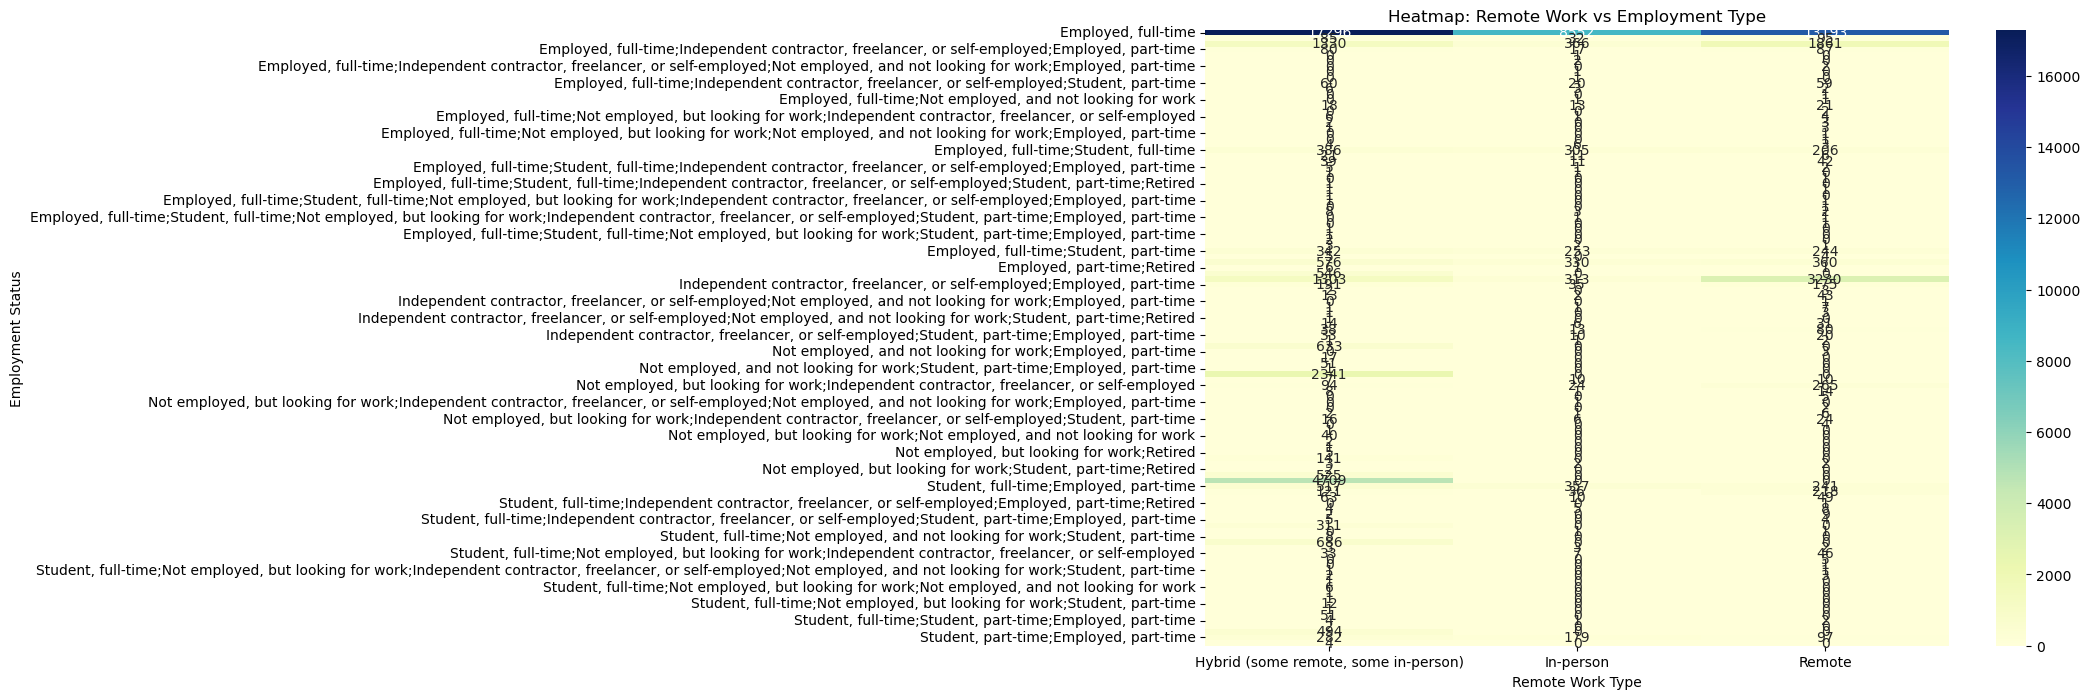

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(remote_employment_cross, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Heatmap: Remote Work vs Employment Type')
plt.xlabel('Remote Work Type')
plt.ylabel('Employment Status')
plt.show()

#### Step 7: Analyzing Programming Language Trends by Region


Analyze the popularity of programming languages by region. Use the `LanguageHaveWorkedWith` column to investigate which languages are most used in different regions.

- Filter data by country or region.

- Visualize the top programming languages by region with a bar plot or heatmap.


In [10]:
## Write your code here
# 1. اختيار الأعمدة المهمة فقط لتسريع العمل
languages_df = df[['Country', 'LanguageHaveWorkedWith']].dropna()

# 2. تفكيك اللغات: تحويل 'Python;Java' إلى صفين منفصلين
languages_df['Language'] = languages_df['LanguageHaveWorkedWith'].str.split(';')
languages_df = languages_df.explode('Language')

# 3. التأكد من تنظيف المسافات الزائدة
languages_df['Language'] = languages_df['Language'].str.strip()

In [11]:
# تحديد الدول التي نريد مقارنتها
target_countries = ['United States of America', 'Egypt', 'Germany' , 'India']
filtered_languages = languages_df[languages_df['Country'].isin(target_countries)]

# حساب تكرار كل لغة داخل كل دولة
lang_region_analysis = filtered_languages.groupby(['Country', 'Language']).size().reset_index(name='Count')

C:\Users\Abdullah\AppData\Local\Temp\ipykernel_11588\3168694655.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_langs = lang_region_analysis.groupby('Country').apply(lambda x: x.nlargest(10, 'Count')).reset_index(drop=True)


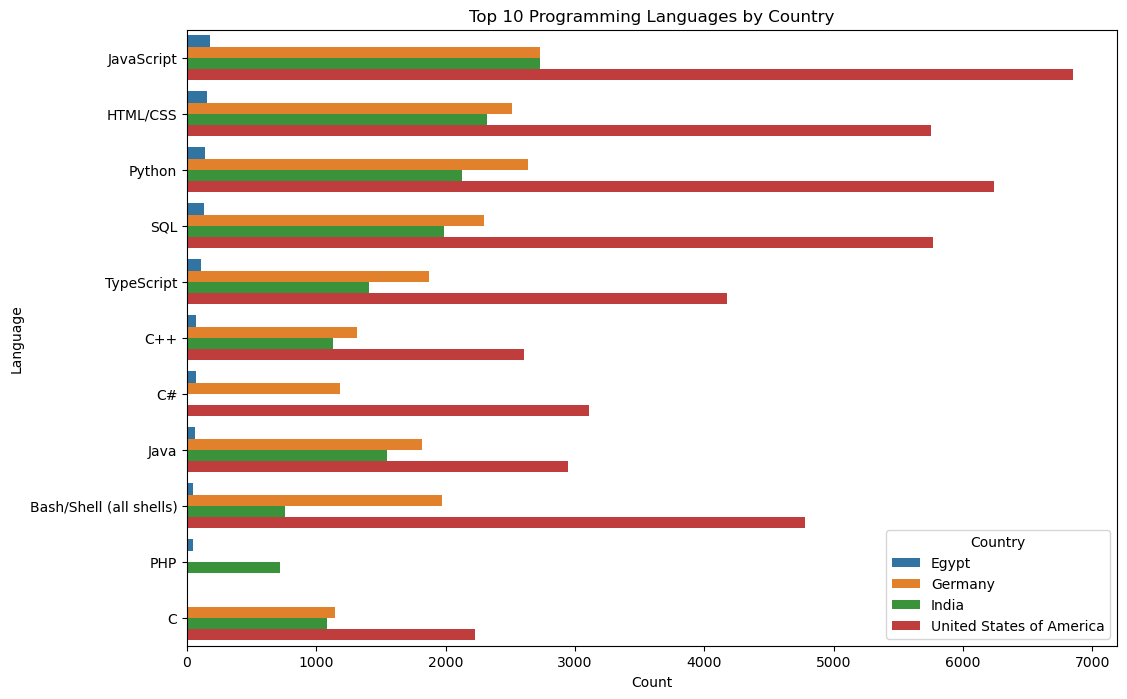

In [12]:
# نأخذ أعلى 10 لغات فقط لكل دولة لتجنب الزحام في الرسم
top_langs = lang_region_analysis.groupby('Country').apply(lambda x: x.nlargest(10, 'Count')).reset_index(drop=True)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_langs, y='Language', x='Count', hue='Country')

plt.title('Top 10 Programming Languages by Country')
plt.show()

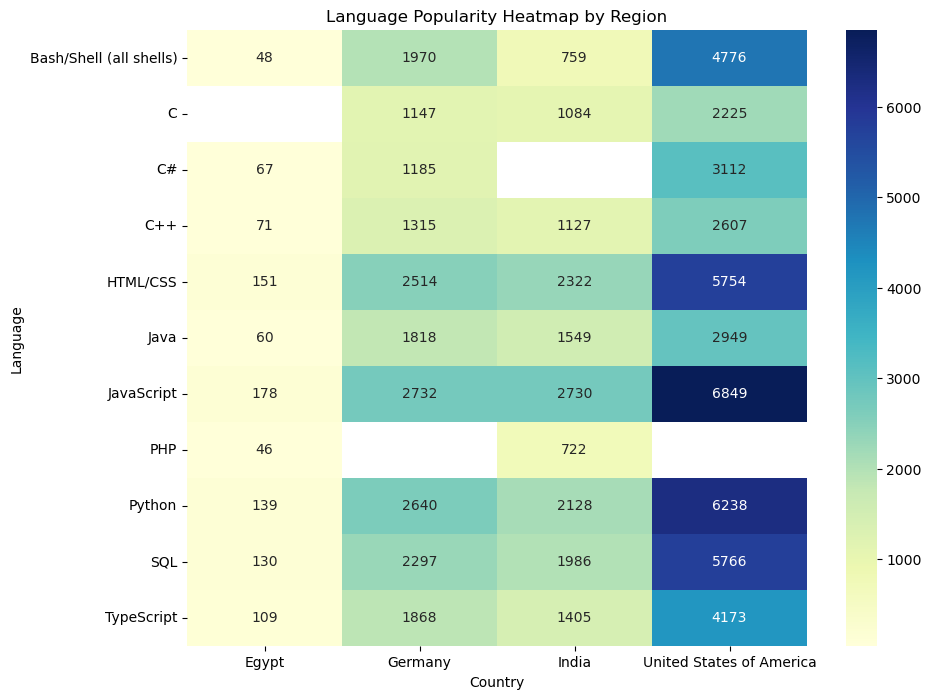

In [13]:
# تحويل البيانات لشكل مصفوفة للحرارة
heatmap_data = pd.crosstab(top_langs['Language'], top_langs['Country'], values=top_langs['Count'], aggfunc='sum')

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='g')
plt.title('Language Popularity Heatmap by Region')
plt.show()

#### Step 8: Correlation Between Experience and Satisfaction


Examine how years of experience (`YearsCodePro`) correlate with job satisfaction (`JobSatPoints_1`). Use a scatter plot to visualize this relationship.


C:\Users\Abdullah\AppData\Local\Temp\ipykernel_11588\3694828235.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['YearsCodePro'] = pd.to_numeric(clean_df['YearsCodePro'], errors='coerce')


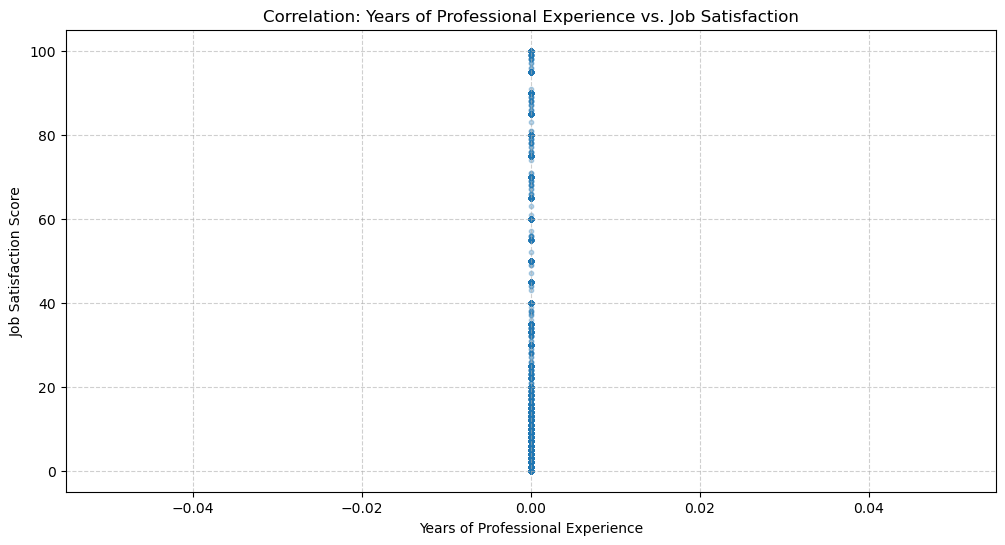

In [14]:
# Remove rows with NaN in either column to avoid plotting errors
clean_df = df.dropna(subset=['YearsCodePro', 'JobSatPoints_1'])

# Convert YearsCodePro to numeric (if not already)
clean_df['YearsCodePro'] = pd.to_numeric(clean_df['YearsCodePro'], errors='coerce')
clean_df['YearsCodePro']

plt.figure(figsize=(12, 6))

# Use regplot to show the trend line
sns.regplot(data=clean_df, x='YearsCodePro', y='JobSatPoints_1', 
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})

plt.title('Correlation: Years of Professional Experience vs. Job Satisfaction')
plt.xlabel('Years of Professional Experience')
plt.ylabel('Job Satisfaction Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Step 9: Educational Background and Employment Type


Explore how educational background (`EdLevel`) relates to employment type (`Employment`). Use cross-tabulation and visualizations to understand if higher education correlates with specific employment types.


In [15]:
# Shortening labels for better plot readability
df['EdLevel_Short'] = df['EdLevel'].str.replace(r'\(.*\)', '', regex=True).str.strip()

# Create the cross-tabulation
ct = pd.crosstab(df['EdLevel_Short'], df['Employment'])
ct

Employment,"Employed, full-time","Employed, full-time;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed","Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time;Retired","Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work","Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Student, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Retired","Employed, full-time;Independent contractor, freelancer, or self-employed;Student, part-time",...,"Student, full-time;Not employed, but looking for work;Not employed, and not looking for work","Student, full-time;Not employed, but looking for work;Not employed, and not looking for work;Student, part-time","Student, full-time;Not employed, but looking for work;Retired","Student, full-time;Not employed, but looking for work;Student, part-time","Student, full-time;Student, part-time","Student, full-time;Student, part-time;Employed, part-time","Student, full-time;Student, part-time;Retired","Student, part-time","Student, part-time;Employed, part-time","Student, part-time;Retired"
EdLevel_Short,,,,,,,,,,,,,,,,,,,,,
Associate degree,1059,9,104,11,0,0,0,0,0,5,...,0,0,0,0,2,0,0,12,24,0
Bachelor’s degree,16806,90,1381,79,0,0,1,0,0,49,...,0,1,0,3,12,1,0,105,184,0
Master’s degree,11011,61,963,45,0,1,0,0,0,26,...,0,0,1,0,2,1,0,26,85,2
Primary/elementary school,160,1,25,1,0,1,0,1,0,0,...,0,0,0,0,5,1,1,48,4,0
Professional degree,2073,8,159,10,1,0,0,0,0,1,...,0,0,0,0,0,0,0,5,5,0
Secondary school,1460,9,181,6,0,0,1,0,0,6,...,0,0,0,2,12,0,1,140,100,0
Some college/university study without earning a degree,3579,15,492,14,0,0,0,0,1,39,...,5,0,0,4,7,4,0,75,103,1
Something else,377,3,41,2,0,0,0,0,0,4,...,0,0,0,1,5,0,0,17,14,1


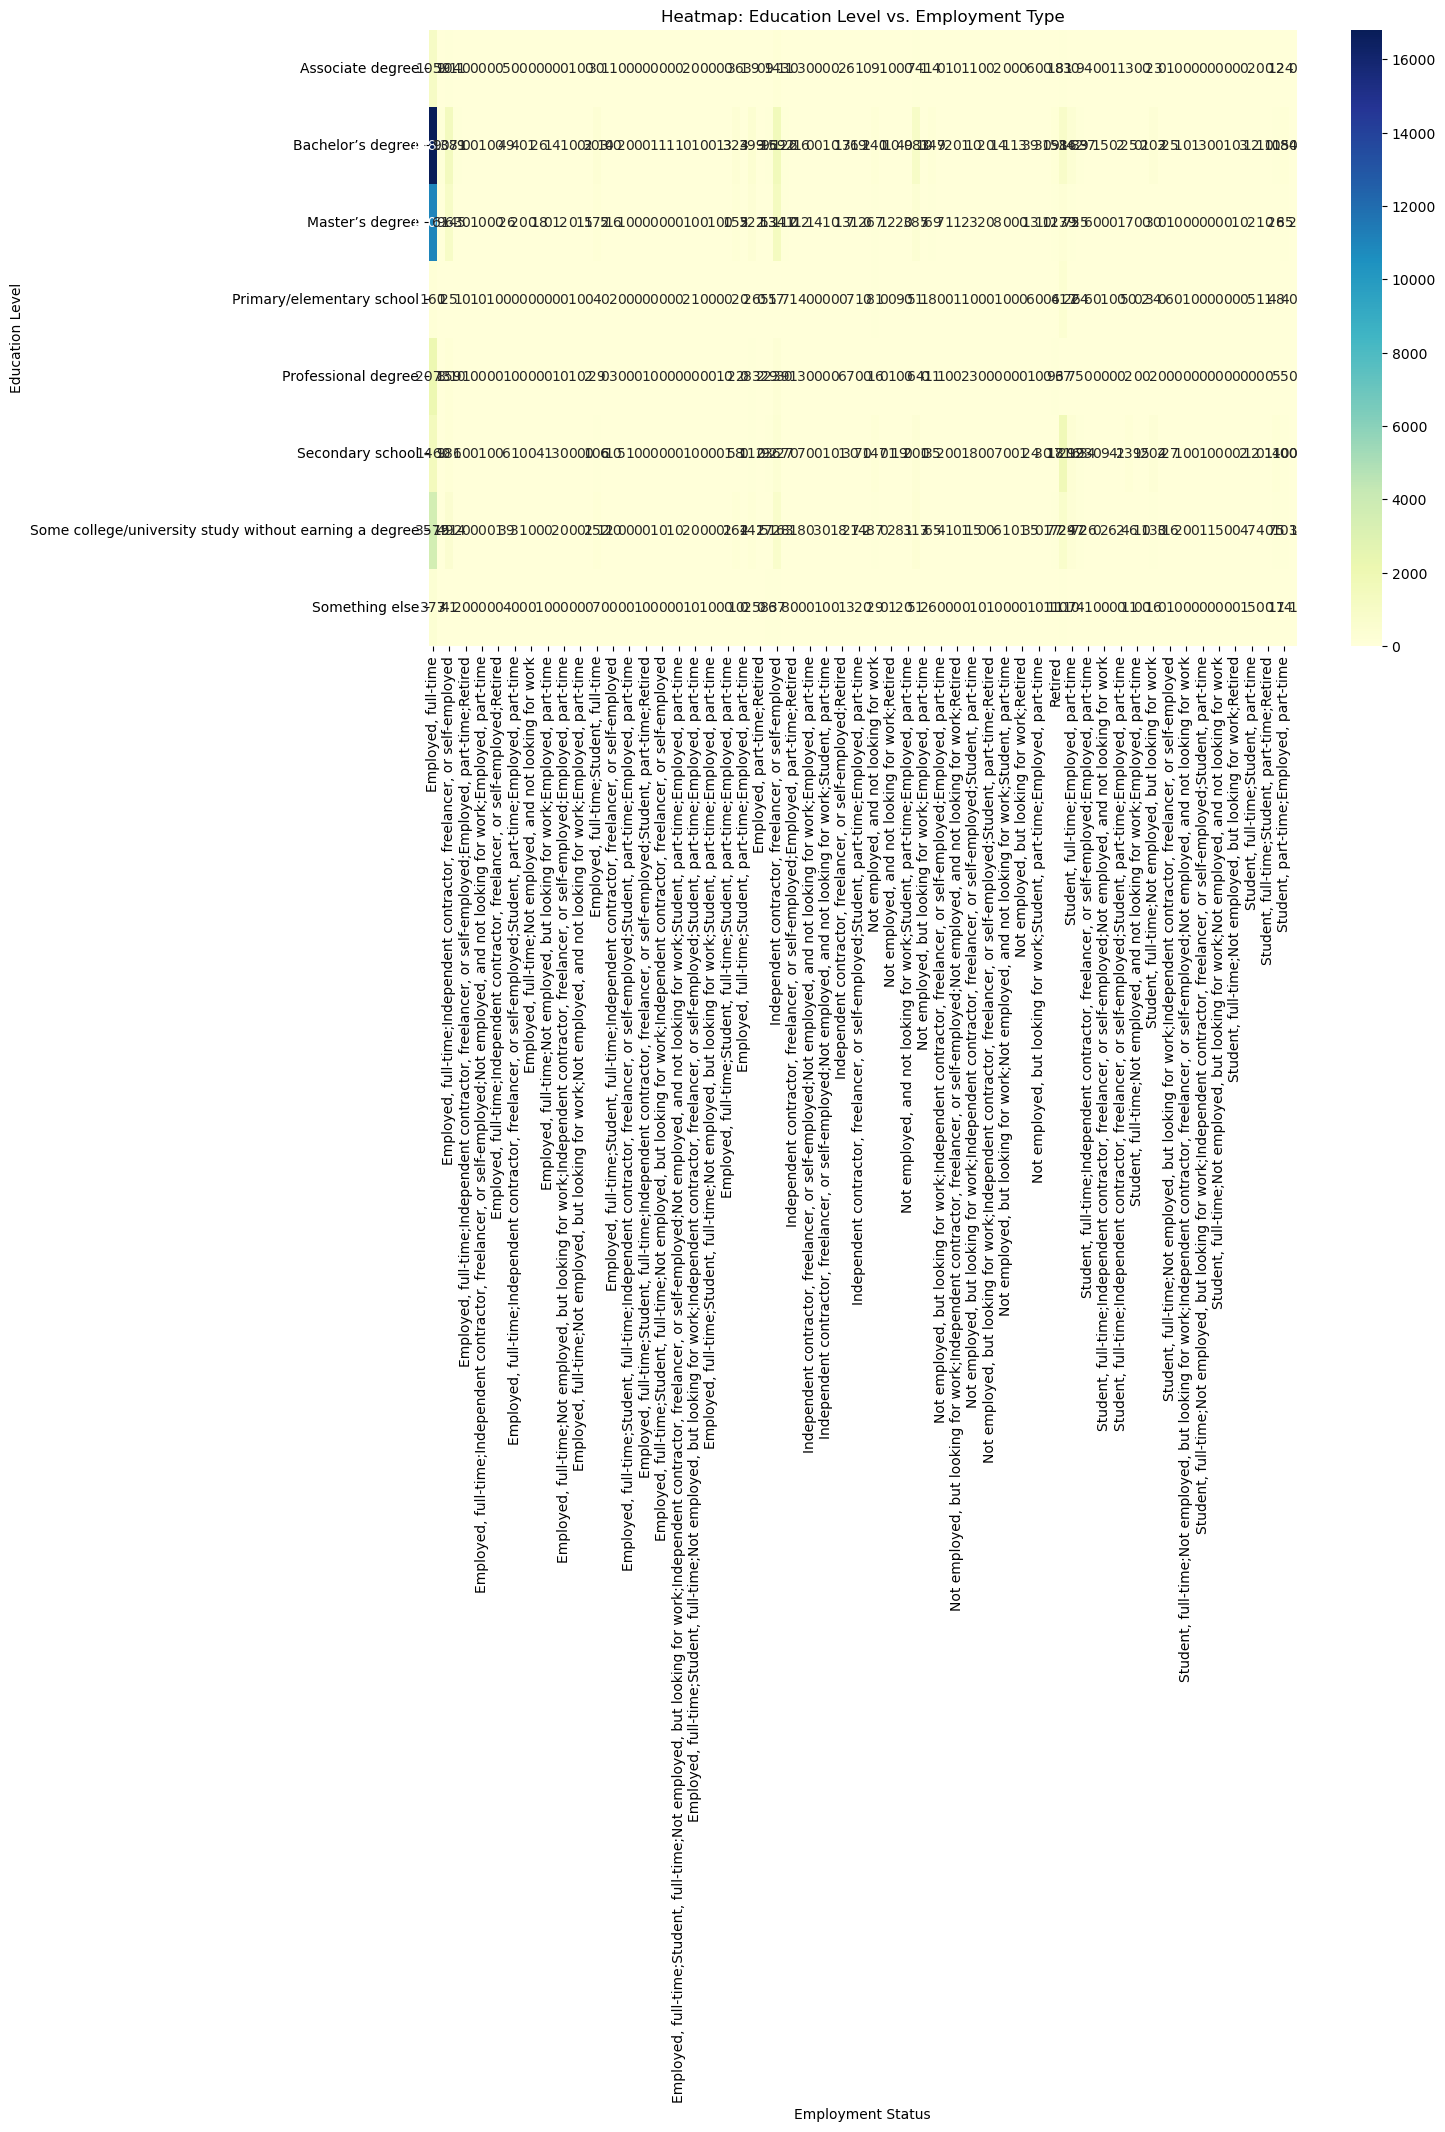

In [16]:
plt.figure(figsize=(14, 8))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Heatmap: Education Level vs. Employment Type')
plt.xlabel('Employment Status')
plt.ylabel('Education Level')
plt.show()

#### Step 10: Save the Cleaned and Analyzed Dataset


After your analysis, save the modified dataset for further use or sharing.


In [17]:
df.to_csv("Cleaned_and_Analyzed_Dataset.csv")

<h2>Summary</h2>


In this revised lab, you:

- Loaded and explored the structure of the dataset.

- Handled missing data effectively.

- Analyzed key variables, including working hours, job satisfaction, and remote work trends.

- Investigated programming language usage by region and examined the relationship between experience and satisfaction.

- Used cross-tabulation to understand educational background and employment type.


Copyright © IBM Corporation. All rights reserved.
